In [ ]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             recall_score)

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("marmal88/skin_cancer")

print(dataset)

In [ ]:
import pandas as pd

df = pd.DataFrame(dataset['train'])
print(df.head())
df.shape

                                               image      image_id  \
0  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024329   
1  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024372   
2  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024418   
3  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024450   
4  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024463   

     lesion_id                 dx dx_type   age     sex     localization  
0  HAM_0002954  actinic_keratoses   histo  75.0  female  lower extremity  
1  HAM_0005389  actinic_keratoses   histo  70.0    male  lower extremity  
2  HAM_0003380  actinic_keratoses   histo  75.0  female  lower extremity  
3  HAM_0005505  actinic_keratoses   histo  50.0    male  upper extremity  
4  HAM_0004568  actinic_keratoses   histo  50.0    male  upper extremity  


(9577, 8)

In [ ]:
df.info()
df.describe().T
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9577 entries, 0 to 9576
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image         9577 non-null   object 
 1   image_id      9577 non-null   object 
 2   lesion_id     9577 non-null   object 
 3   dx            9577 non-null   object 
 4   dx_type       9577 non-null   object 
 5   age           9522 non-null   float64
 6   sex           9577 non-null   object 
 7   localization  9577 non-null   object 
dtypes: float64(1), object(7)
memory usage: 598.7+ KB


['image',
 'image_id',
 'lesion_id',
 'dx',
 'dx_type',
 'age',
 'sex',
 'localization']

In [ ]:
print("\nMissing values per column:")
display(df.isnull().sum())

print('\nDuplicate values per column:')
display(df.drop(columns=['image']).duplicated().sum())


Missing values per column:


,0
image,0
image_id,0
lesion_id,0
dx,0
dx_type,0
age,55
sex,0
localization,0



Duplicate values per column:


np.int64(0)

In [ ]:
print('\nFill missing values in \'age\' with the most common age:')
df['age'] = df['age'].fillna(df['age'].median())
display(df.isnull().sum())


Fill missing values in 'age' with the most common age:


,0
image,0
image_id,0
lesion_id,0
dx,0
dx_type,0
age,0
sex,0
localization,0


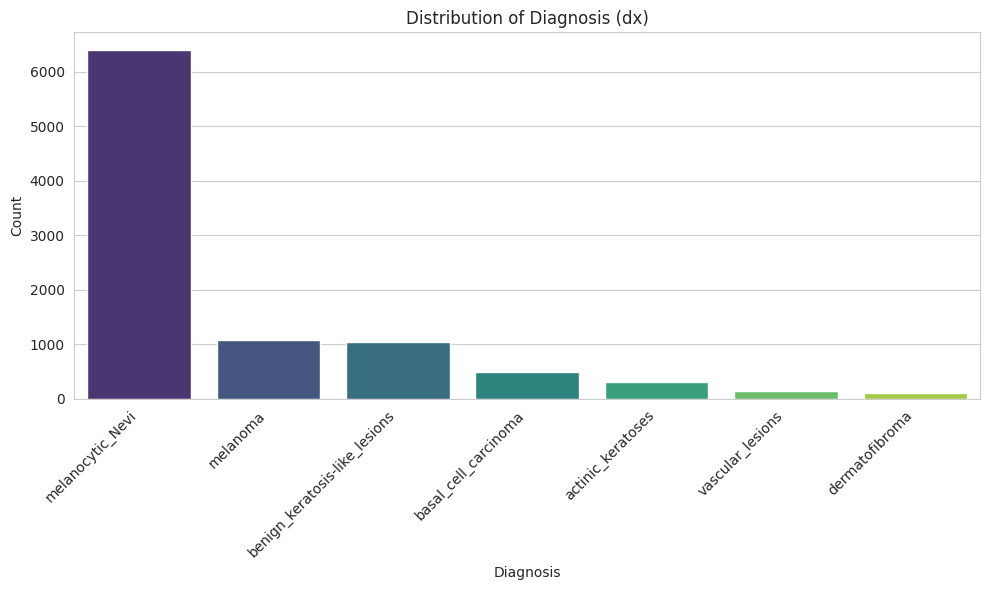

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# 1. Distribution of 'dx' (diagnosis)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution of Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

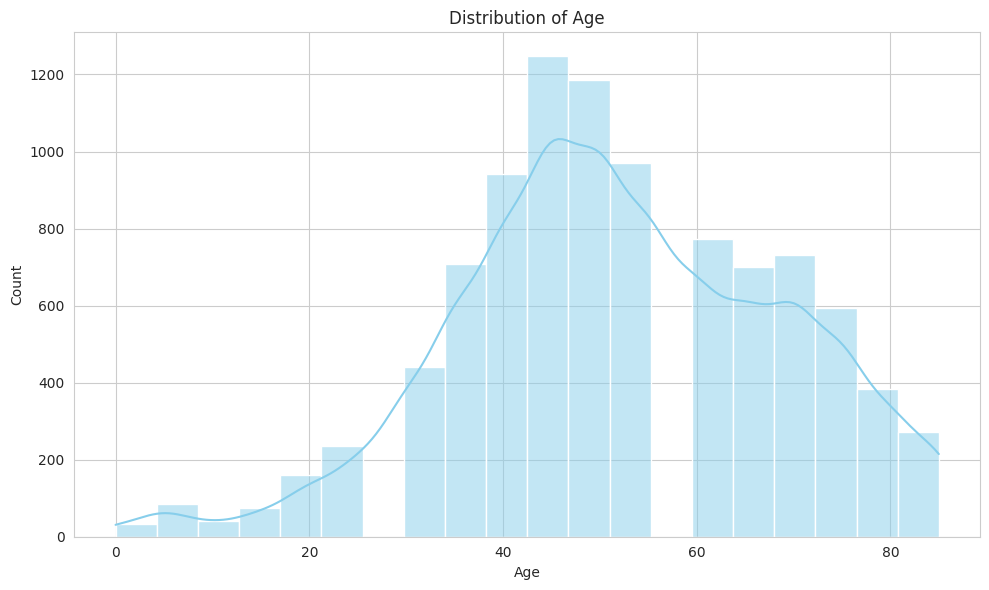

In [ ]:
# 2. Distribution of 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', kde=True, bins=20, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

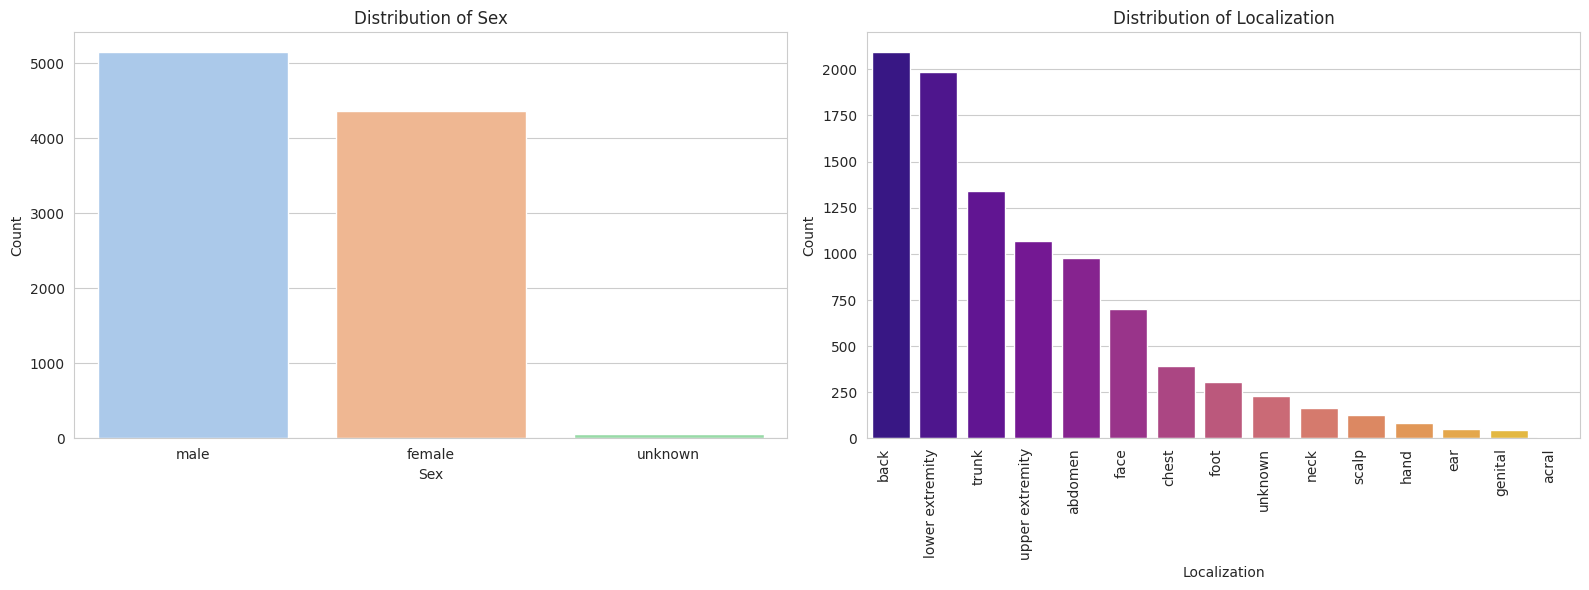

In [ ]:
# 3. Distributions of 'sex' and 'localization'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='sex', ax=axes[0], palette='pastel', order=df['sex'].value_counts().index)
axes[0].set_title('Distribution of Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='localization', ax=axes[1], palette='plasma', order=df['localization'].value_counts().index)
axes[1].set_title('Distribution of Localization')
axes[1].set_xlabel('Localization')
axes[1].set_ylabel('Count')
plt.setp(axes[1].get_xticklabels(), rotation=90, horizontalalignment='right')

plt.tight_layout()
plt.show()

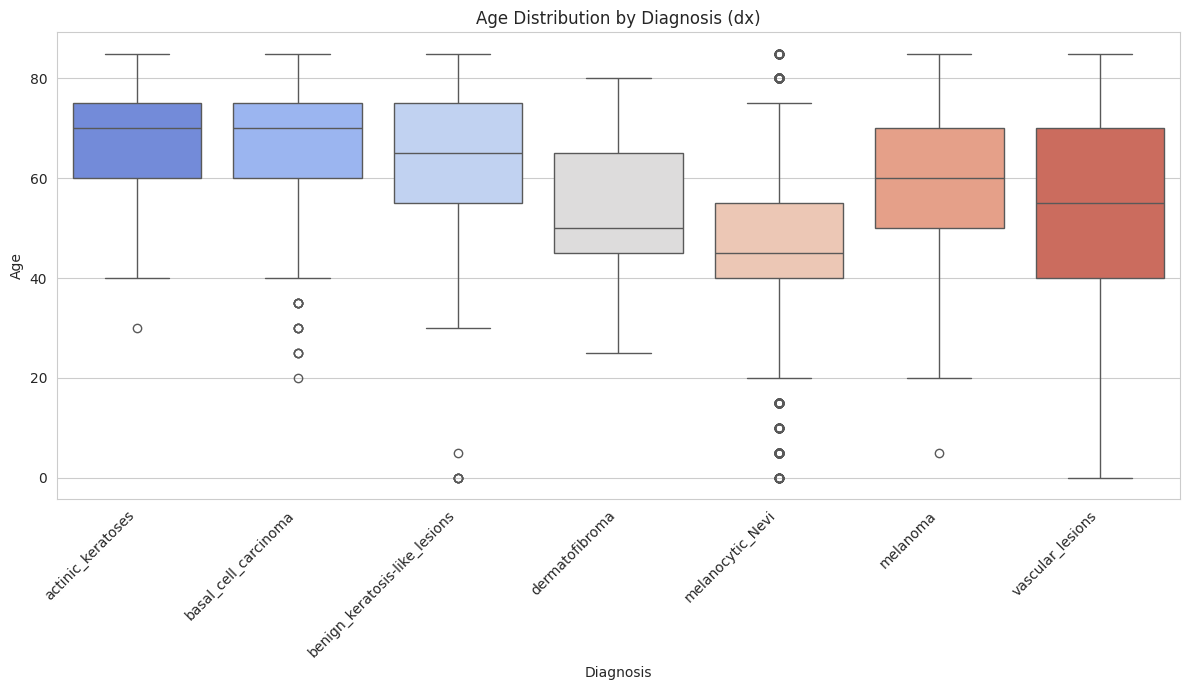

In [ ]:
# 4. Age distribution by 'dx'
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='dx', y='age', palette='coolwarm')
plt.title('Age Distribution by Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_encoded = pd.get_dummies(df, columns=['dx'], prefix='dx')

# Display the first few rows of the DataFrame with the new encoded columns
display(df_encoded.head())

# Display the names of the new columns created by one-hot encoding
print(f"\nNew columns created: {df_encoded.columns[df_encoded.columns.str.startswith('dx_')].tolist()}")

,image,image_id,lesion_id,dx_type,age,sex,localization,dx_actinic_keratoses,dx_basal_cell_carcinoma,dx_benign_keratosis-like_lesions,dx_dermatofibroma,dx_melanocytic_Nevi,dx_melanoma,dx_vascular_lesions
0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024329,HAM_0002954,histo,75.0,female,lower extremity,True,False,False,False,False,False,False
1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024372,HAM_0005389,histo,70.0,male,lower extremity,True,False,False,False,False,False,False
2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024418,HAM_0003380,histo,75.0,female,lower extremity,True,False,False,False,False,False,False
3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024450,HAM_0005505,histo,50.0,male,upper extremity,True,False,False,False,False,False,False
4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024463,HAM_0004568,histo,50.0,male,upper extremity,True,False,False,False,False,False,False



New columns created: ['dx_type', 'dx_actinic_keratoses', 'dx_basal_cell_carcinoma', 'dx_benign_keratosis-like_lesions', 'dx_dermatofibroma', 'dx_melanocytic_Nevi', 'dx_melanoma', 'dx_vascular_lesions']
